Number of non-isomorphic trees on 8 vertices: 23

Rank  1: Tree ID = 22, Energy = 5.291503
Rank  2: Tree ID = 21, Energy = 6.774108
Rank  3: Tree ID = 18, Energy = 7.115295
Rank  4: Tree ID = 11, Energy = 7.211103
Rank  5: Tree ID = 14, Energy = 7.211103
Rank  6: Tree ID = 12, Energy = 7.384646
Rank  7: Tree ID = 20, Energy = 8.152756
Rank  8: Tree ID = 13, Energy = 8.261125
Rank  9: Tree ID =  7, Energy = 8.312845
Rank 10: Tree ID = 17, Energy = 8.375131
Rank 11: Tree ID = 15, Energy = 8.424292
Rank 12: Tree ID =  2, Energy = 8.472136
Rank 13: Tree ID = 10, Energy = 8.519258
Rank 14: Tree ID =  4, Energy = 8.565187
Rank 15: Tree ID =  8, Energy = 8.647053
Rank 16: Tree ID = 16, Energy = 8.720566
Rank 17: Tree ID =  1, Energy = 8.762573
Rank 18: Tree ID =  6, Energy = 8.828427
Rank 19: Tree ID = 19, Energy = 9.291503
Rank 20: Tree ID =  5, Energy = 9.331737
Rank 21: Tree ID =  3, Energy = 9.409260
Rank 22: Tree ID =  9, Energy = 9.445871
Rank 23: Tree ID =  0, Energy = 9.517541


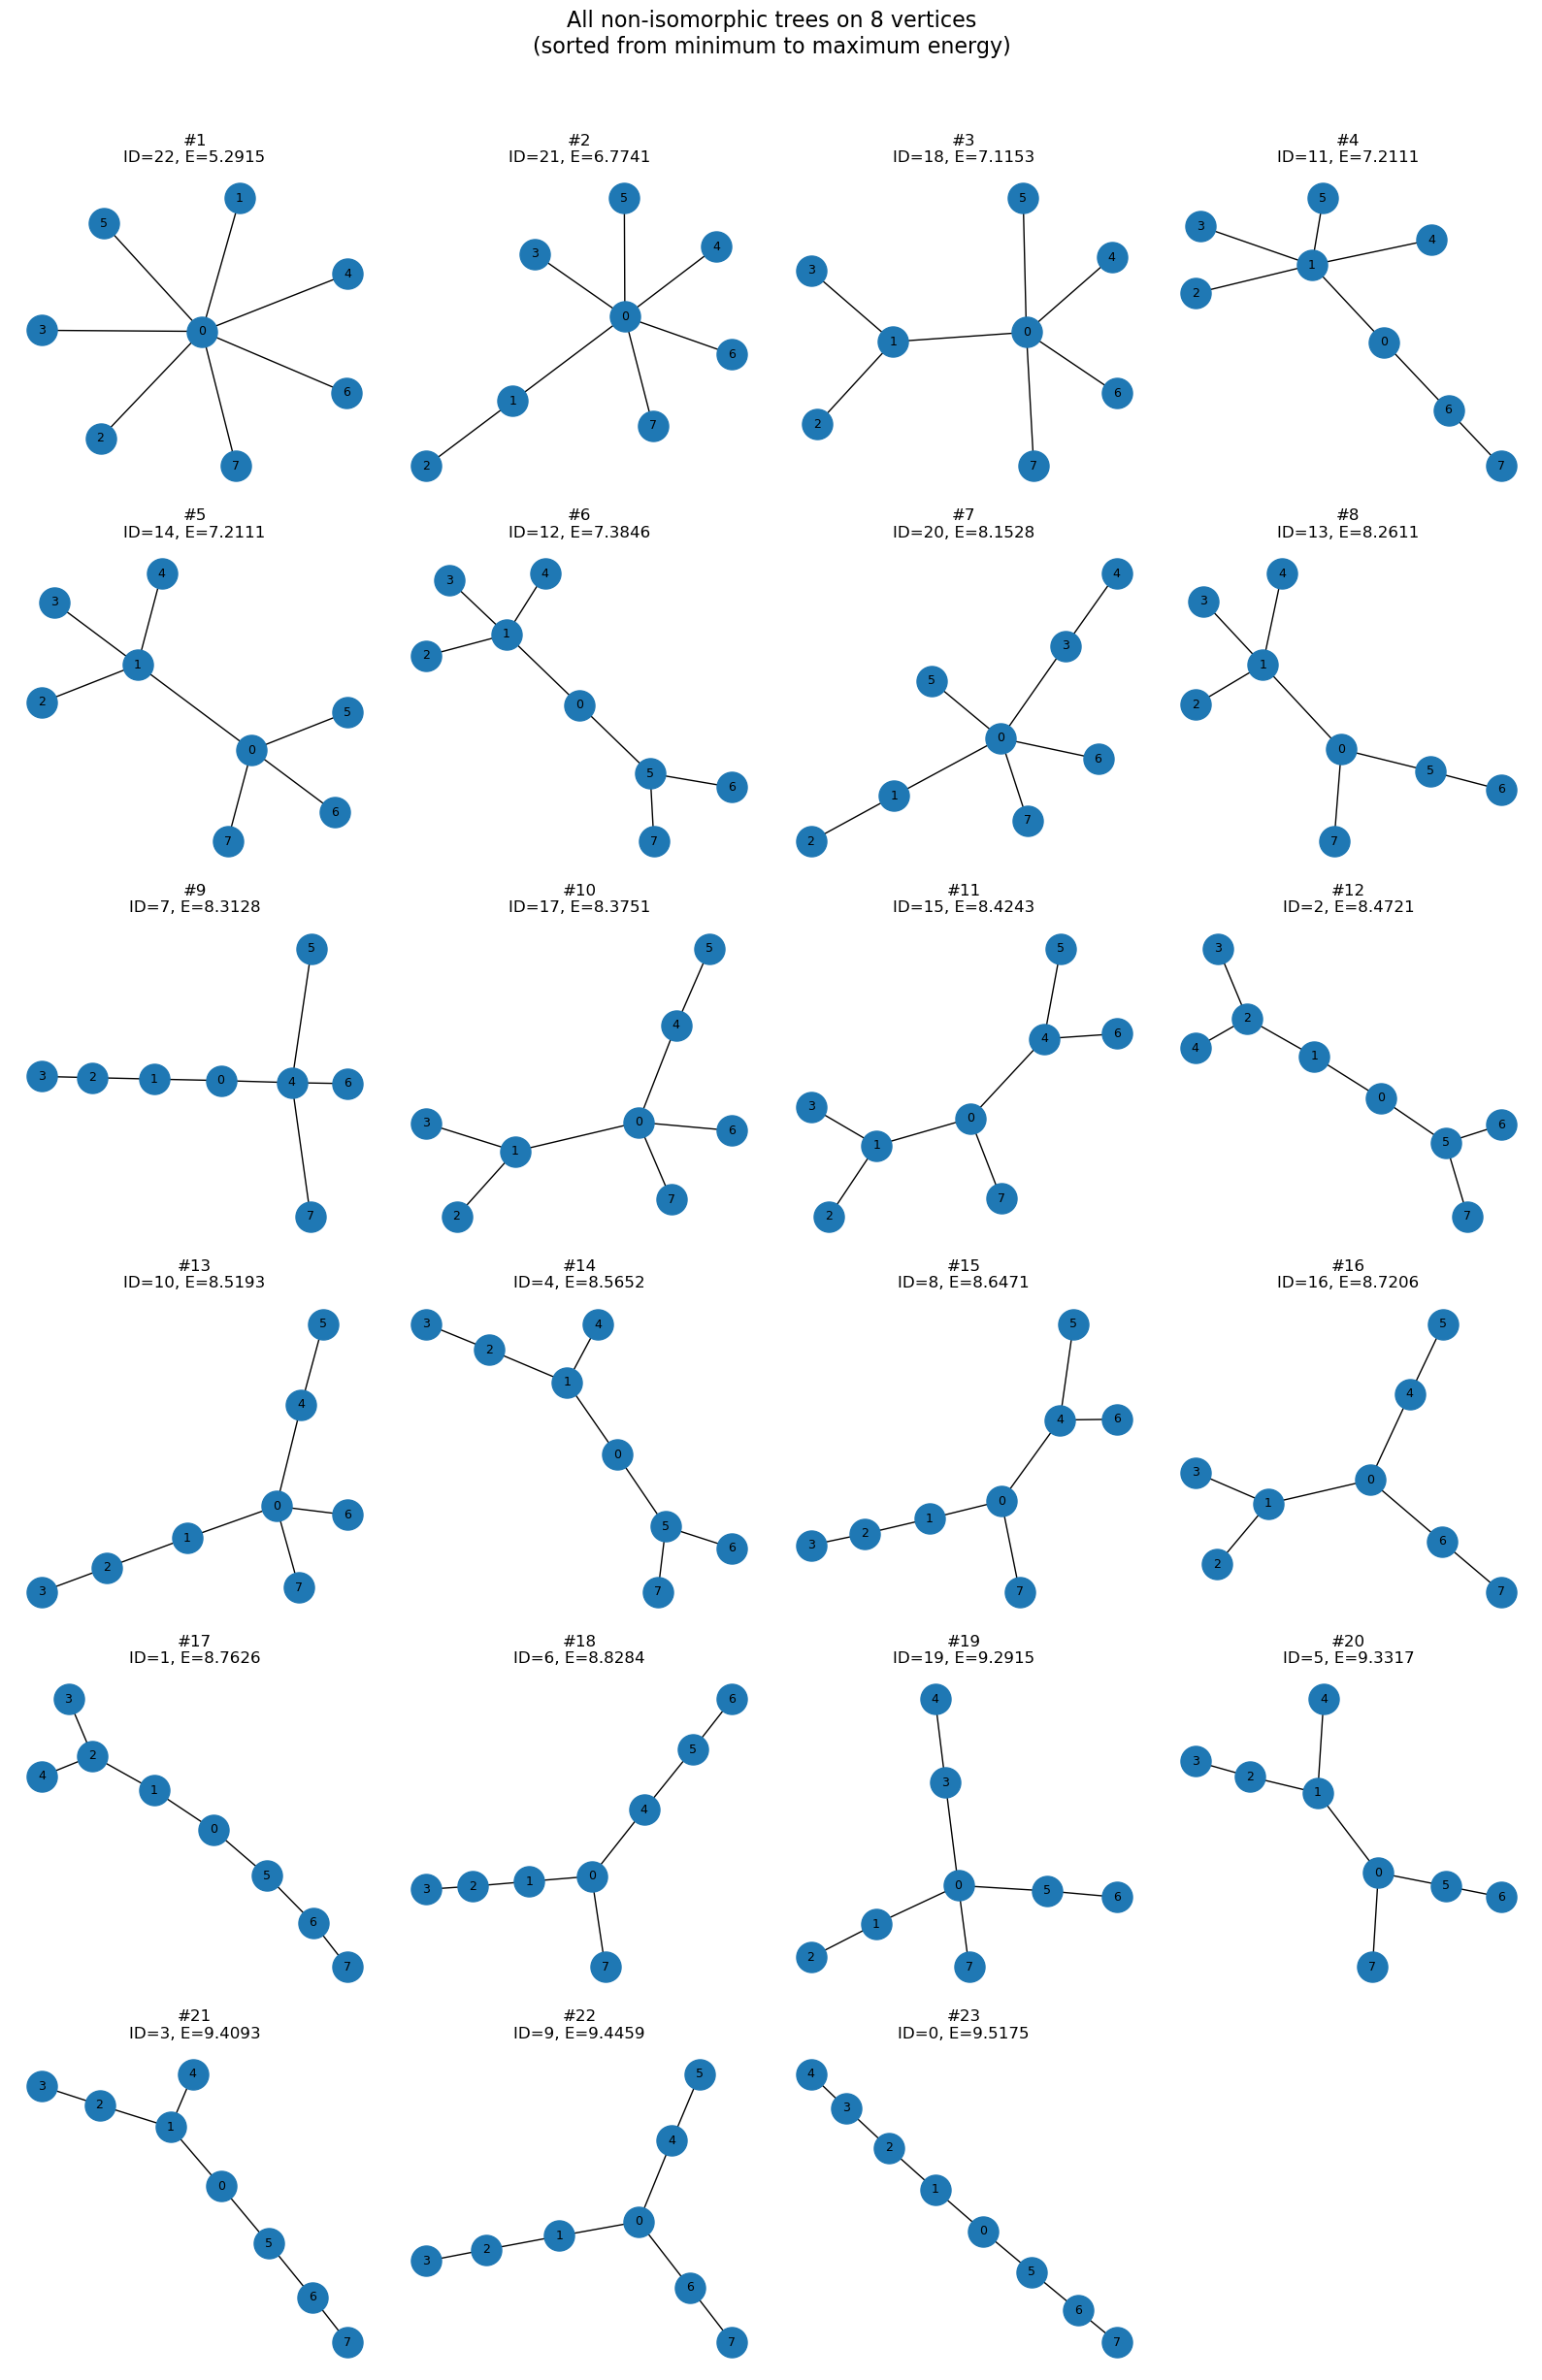

In [2]:
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


def graph_energy(G):
    """
    Compute the graph energy:
        E(G) = sum of absolute values of adjacency eigenvalues.
    """
    A = nx.to_numpy_array(G)
    eigvals = np.linalg.eigvalsh(A)
    return float(np.sum(np.abs(eigvals)))


def all_trees_sorted_by_energy(n):
    """
    Generate all non-isomorphic trees on n vertices and sort them by energy.
    Returns a list of tuples:
        (energy, tree_index, graph)
    """
    results = []

    for i, T in enumerate(nx.nonisomorphic_trees(n)):
        E = graph_energy(T)
        results.append((E, i, T.copy()))

    results.sort(key=lambda x: x[0])
    return results


def draw_all_trees(results, n, cols=4, figsize_scale=4):
    """
    Draw all trees in sorted order from minimum energy to maximum energy.
    """
    total = len(results)
    rows = math.ceil(total / cols)

    plt.figure(figsize=(figsize_scale * cols, figsize_scale * rows))

    for k, (E, tree_id, T) in enumerate(results, start=1):
        plt.subplot(rows, cols, k)

        # Spring layout for drawing
        pos = nx.spring_layout(T, seed=42)

        nx.draw(
            T,
            pos,
            with_labels=True,
            node_size=500,
            font_size=9,
        )

        plt.title(f"#{k}\nID={tree_id}, E={E:.4f}")
        plt.axis("off")

    plt.suptitle(
        f"All non-isomorphic trees on {n} vertices\n(sorted from minimum to maximum energy)",
        fontsize=16,
        y=1.02
    )
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    n = 8   # change this
    results = all_trees_sorted_by_energy(n)

    print(f"Number of non-isomorphic trees on {n} vertices: {len(results)}")
    print()

    for rank, (E, tree_id, _) in enumerate(results, start=1):
        print(f"Rank {rank:2d}: Tree ID = {tree_id:2d}, Energy = {E:.6f}")

    draw_all_trees(results, n, cols=4)